# 📝 Instrucciones

## Sistema de clasificación de imágenes

El conjunto de datos se compone de fotos de perros y gatos proporcionadas como un subconjunto de fotos de uno mucho más grande de 3 millones de fotos anotadas manualmente. Estos datos se obtuvieron a través de una colaboración entre **Petfinder.com** y **Microsoft**.

El conjunto de datos se usó originalmente como un **CAPTCHA**, es decir, una tarea que se cree que un humano encuentra trivial, pero que una máquina no puede resolver, que se usa en sitios web para distinguir entre usuarios humanos y bots. La tarea se denominó **"Asirra"**. Cuando se presentó "Asirra", se mencionó "que los estudios de usuarios indican que los humanos pueden resolverlo el 99,6% de las veces en menos de 30 segundos". A menos que se produzca un gran avance en la visión artificial, esperamos que los ordenadores no tengan más de 1/54.000 posibilidades de resolverlo.

En el momento en que se publicó la competencia, el resultado de última generación se logró con un **SVM** y se describió en un artículo de 2007 con el título *"Ataques de Machine Learning contra el CAPTCHA de Asirra"* (PDF) que logró una precisión de clasificación del 80%. Fue este documento el que demostró que la tarea ya no era una tarea adecuada para un CAPTCHA poco después de que se propusiera la tarea.

---

### Paso 1: Carga del conjunto de datos
El conjunto de datos se encuentra en este [link](https://www.microsoft.com/en-us/download/details.aspx?id=54765). Descarga la carpeta y descomprime los archivos. Ahora tendrás una carpeta con el dataset y una carpeta llamada `train` que contiene más de 25.000 archivos de imagen (formato .jpg) de perros y gatos. Las fotos están etiquetadas por su nombre de archivo, con la palabra `dog` o `cat`.

### Paso 2: Visualiza la información de entrada
El primer paso cuando nos enfrentamos a un problema de clasificación de imágenes es obtener toda la información posible a través de ellas. Por lo tanto, carga e imprime las primeras nueve fotos de perros en una sola figura. Repite lo mismo para los gatos. Puedes ver que las fotos son a color y tienen diferentes formas y tamaños.

Esta variedad de tamaños y formatos debe solucionarse antes de entrenar el modelo. Asegúrate de que todas tengan un tamaño fijo de **200x200 píxeles**.

Como podrás ver, son una gran cantidad de imágenes, asegúrate de seguir las siguientes normas:

* **Si tienes más de 12 gigabytes de RAM:** usa la API de procesamiento de imágenes de Keras para cargar las 25.000 fotos en el conjunto de datos de entrenamiento y remodelarlas a fotos cuadradas de 200×200 píxeles. La etiqueta también debe determinarse para cada foto en función de los nombres de archivo. Se debe guardar una tupla de fotos y etiquetas.
* **Si no tienes más de 12 gigabytes de RAM:** carga las imágenes progresivamente usando la clase Keras `ImageDataGenerator` y la función `flow_from_directory()`. Esto será más lento de ejecutar, pero se ejecutará en hardware de menor capacidad. Esta función prefiere que los datos se dividan en directorios `train` y `test` separados, y debajo de cada directorio para tener un subdirectorio para cada clase.

Una vez tengas todas las imágenes procesadas, crea un objeto `ImageDataGenerator` para datos de entrenamiento y prueba. Luego pasa la carpeta que tiene datos de entrenamiento al objeto `trdata` y, de manera similar, pasa la carpeta que tiene datos de prueba al objeto `tsdata`. De esta forma, se etiquetarán las imágenes automáticamente y estará todo listo para entrar a la red.

---

### Paso 3: Construye una RNA
Cualquier clasificador que se ajuste a este problema tendrá que ser robusto porque algunas imágenes muestran al gato o al perro en una esquina o tal vez a 2 gatos o perros en la misma foto. Si has podido investigar algunas de las implementaciones de los ganadores de otras competiciones también relacionadas con imágenes, verás que **VGG16** es una arquitectura de CNN utilizada para ganar la competencia de Kaggle ILSVR (Imagenet) en 2014. Se considera una de las arquitecturas de modelos de visión con mejores resultados hasta la fecha.

Utiliza la siguiente arquitectura de prueba:

```python
model = Sequential()
model.add(Conv2D(input_shape = (224,224,3), filters = 64, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 64,kernel_size = (3,3),padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Flatten())
model.add(Dense(units = 4096,activation = "relu"))
model.add(Dense(units = 4096,activation = "relu"))
model.add(Dense(units = 2, activation = "softmax"))
```

### Paso 4: Optimiza el modelo anterior
Importa el método ModelCheckpoint y EarlyStopping de Keras. Crea un objeto de ambos y pásalo como funciones callback a fit_generator.

Carga el mejor modelo de los anteriores y utiliza el conjunto de test para hacer predicciones.

### Paso 5: Guarda el modelo
Almacena el modelo en la carpeta correspondiente.

In [12]:
import os
import cv2
import time
# Antes de empezar, vamos a asegurarnos de usar torch con directml en lugar de tensorflow, ya que nuestra gpu no es nvidia.
os.environ["KERAS_BACKEND"] = "torch"
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision import datasets, transforms
from PIL import Image, ImageFile
from torch.utils.data import DataLoader, random_split
# Previamente, Instalamos ROCm que es como un transportador de CUDA para AMD Basicamente engañamos a PyTorch para que crea que tenemos nucleos cuda.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device_name = f"Dispositivo detectado: {torch.cuda.get_device_name(0)}"
device_name

'Dispositivo detectado: AMD Radeon RX 7600 XT'

In [13]:
# Pegandome de palos me di cuenta que hay algunas imagenes corruptas o truncadas que no se pueden leer con OpenCV que es nuestro motor de lectura para la GPU.
ImageFile.LOAD_TRUNCATED_IMAGES = True
# Esta funcion revisa cada imagen y copia las que esten bien a una nueva carpeta.
def crear_dataset_limpio(origen, destino):
    if not os.path.exists(destino):
        os.makedirs(destino)
        
    categories = ['Cat', 'Dog']
    #Inicializamos la cuenta de procesados y eliminados
    total_processed = 0
    total_droped = 0

    for cat in categories:
        path_origen = os.path.join(origen, cat)
        path_destino = os.path.join(destino, cat)
        
        if not os.path.exists(path_destino):
            os.makedirs(path_destino)
            
        print(f" Procesando categoria: {cat}")
        
        for archivo in os.listdir(path_origen):
            # Nos quedamos con las extenciones de imagen que nos interesan.
            if not archivo.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
                
            file_path = os.path.join(path_origen, archivo)
            dest_file_path = os.path.join(path_destino, archivo)
            
            try:
                # Verificamos que la imagen se pueda abrir con PIL (esto detecta archivos corruptos o truncados)
                with Image.open(file_path) as img:
                    img.load()
                    # Si la imagen tiene 2 canales, la convertimos a RGB puro
                    if img.mode != 'RGB':
                        img = img.convert('RGB')
                
                # Verificación final con OpenCV (Tengo entendido que simula como lo leera la GPU)
                img_cv = cv2.imread(file_path, cv2.IMREAD_COLOR)
                
                if img_cv is None or img_cv.shape[2] != 3:
                    raise ValueError("Imagen no valida")

                # Si todo salio bien usamos cv2.imwrite para asegurar que el archivo resultante sea un JPEG estándar de 3 canales
                cv2.imwrite(dest_file_path, img_cv)
                total_procesadas += 1
                
            except Exception as e:
                # Si hay algun error damos la imagen por corrupta.
                total_eliminadas += 1
    # Imprimimos los resultados finales
    print(f"Imagenes validas guardadas en: {destino}")
    print(f"Total procesadas con exito: {total_processed}")
    print(f"Total eliminadas: {total_droped}")


# Declaramos las rutas de origen de las imagenes y la ruta de destino.
ruta_sucia = '../data/raw/PetImages/'
ruta_limpia = '../data/processed/PetImages_Clean/'

#Si ya la carpeta de imagenes limpias existe, no hacemos nada.
if not os.path.exists(ruta_limpia):
   crear_dataset_limpio(ruta_sucia, ruta_limpia)

In [14]:
# Establecemos la ruta del dataset con Path la libreria ImageFolder aparentemente se lleva mejor con objetos Path.
ruta_limpia = Path(ruta_limpia)
# y los parametros de imagen de le cambie de 200 a 250 ajustando y optimizando parametros
IMG_SIZE = 224
# El bacth es como una paquete de imagenes en este caso, cada interacion del modelo se le da un paquete de imagenes para entrenar, el tamaño del paquete es 20
BATCH_SIZE = 128
# Los epochs son las veces que el modelo va a ver todo el dataset, en este caso 12 veces. poco puede ocacionar underfitting y mucho overfitting.
EPOCHS = 10
SEED = 42

# Este son un conjunto de transformaciones que se le aplican a cada imagen antes de ser procesada por el modelo, esto ayuda a mejorar la generalizacion del modelo y evitar el overfitting.
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),          # ← NUEVO
    transforms.RandomRotation(10),                    # ← NUEVO
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # ← NUEVO
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), # ← NUEVO
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),  # ← Valores ImageNet
                        std=(0.229, 0.224, 0.225))
])
# transform = transforms.Compose([
#     transforms.Resize((IMG_SIZE, IMG_SIZE)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
# ])
#Ya Tenemos el data set limpio ahora imprimamos las clases y la cantidad.
full_dataset = datasets.ImageFolder(root=str(ruta_limpia), transform=transform)

print(full_dataset.class_to_idx)
print("Total imagenes:", len(full_dataset))

{'Cat': 0, 'Dog': 1}
Total imagenes: 24997


In [15]:
# En anteriores ejercicios hemos dividido el dataset con train_split, pero en este caso ya que hablamos de imagenes, Vamos a intentar un random_split.
# Primero establecemos la divicion 80-20.
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

# Inicializamos el torch.generator con una semilla, esto se lo pasamos al random_split.
g = torch.Generator().manual_seed(SEED)
# Y Dividimos.
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size], generator=g)
# Ahora creamos los dataloaders que son los objetos que se encargan de cargar las imagenes en memoria en cada iteracion del entrenamiento
# Este carga el batch que le especificamos y las mezcla con shuffle=True. 
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)
# Imprimimos cuantas imagenes tenemos en ambos sets
print("Train:", len(train_dataset))
print("Test:", len(test_dataset))

Train: 19997
Test: 5000


In [16]:
# #Vamos a cargar las imagenes con "keras image_dataset_from_directory" como especifica el ejercicio para >12 de ram, le ponemos "label_mode="binari" ya que tratamos con dos clases(gatos y perros)
# # Vamos a hacer la divicion de una vez usando el ramdom seed de 42 y una la division 80-20
# class CatDogCNN(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.features = nn.Sequential(
#             nn.Conv2d(3, 32, kernel_size=3, padding=1),
#             nn.BatchNorm2d(32),              # ← NUEVO
#             nn.ReLU(),
#             nn.MaxPool2d(2),
#             nn.Dropout2d(0.2),               # ← NUEVO

#             nn.Conv2d(32, 64, kernel_size=3, padding=1),
#             nn.BatchNorm2d(64),              # ← NUEVO
#             nn.ReLU(),
#             nn.MaxPool2d(2),
#             nn.Dropout2d(0.2),               # ← NUEVO

#             nn.Conv2d(64, 128, kernel_size=3, padding=1),
#             nn.BatchNorm2d(128),             # ← NUEVO
#             nn.ReLU(),
#             nn.MaxPool2d(2),
#             nn.Dropout2d(0.3),               # ← NUEVO
            
#             nn.Conv2d(128, 256, kernel_size=3, padding=1),
#             nn.BatchNorm2d(256),             # ← NUEVO
#             nn.ReLU(),
#             nn.AdaptiveAvgPool2d((1, 1)),
#         )

#         self.classifier = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(256, 128),             # ← Añadir capa intermedia
#             nn.ReLU(),
#             nn.Dropout(0.5),
#             nn.Linear(128, 2)
#         )

#     def forward(self, x):
#         x = self.features(x)
#         x = self.classifier(x)
#         return x

In [17]:
#Vamos a cargar las imagenes con "keras image_dataset_from_directory" como especifica el ejercicio para >12 de ram, le ponemos "label_mode="binari" ya que tratamos con dos clases(gatos y perros)
# Vamos a hacer la divicion de una vez usando el ramdom seed de 42 y una la division 80-20
class CatDogCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [18]:
#Vamos a ver si realmente destecta dos clases, para esto imprimimos el atributo "class_names" del dataset
# class_names = total_data.class_names
# class_names

In [19]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for i, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        if i % 50 == 0:  # 👈 verbose cada 50 batches
            print(f"  [batch {i}/{len(loader)}] loss={loss.item():.4f}")

    return total_loss / len(loader), correct / total



@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total
    accuracy = correct / total
    
    # Métricas adicionales (opcionales)
    from sklearn.metrics import precision_recall_fscore_support
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='binary', zero_division=0
    )
    
    return avg_loss, accuracy, precision, recall, f1

In [20]:
# Vamos a hacer u multiplot con imshow para mostrar los primeros 9 perros y 9 gatos.
# for clase in class_names:
#     clase_es = "Perro" if clase == "Dog" else "Gato"
#     plt.figure(figsize=(10, 10))
#     count = 0

#     for images, labels in total_data.take(5): 
#         for i in range(len(images)):

#             label = int(labels[i].numpy().item())

#             if class_names[label] == clase and count < 9:
#                 ax = plt.subplot(3, 3, count + 1)
#                 plt.imshow(images[i].numpy().astype("uint8"))
#                 plt.title(clase_es)
#                 plt.axis("off")
#                 count += 1

#         if count == 9:
#             break

#     plt.suptitle(f"Primeras 9 fotos de {clase_es}s")


# Analizis Hasta ahora

In [21]:
model = CatDogCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)  # ← L2 regularization
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)  # ← Reduce cada 5 épocas

In [22]:
#Vamos a provar distintos parametros usando el RandomForestClassifier
folder = Path("../data/processed/models/catdogs/")
folder.mkdir(parents=True, exist_ok=True)
path = folder / "model_torch_directml.pt"
history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "epoch_time": [],
    "images_per_sec": []
}

def train_loop(epochs=EPOCHS):
    num_images = len(train_loader.dataset)

    for epoch in range(epochs):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        start_time = time.perf_counter()

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        test_loss, test_acc, precision, recall, f1 = evaluate(
            model, test_loader, criterion, device
        )
        scheduler.step()

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        end_time = time.perf_counter()

        epoch_time = end_time - start_time
        images_per_sec = num_images / epoch_time

        history["epoch"].append(epoch + 1)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["precision"].append(precision)
        history["recall"].append(recall)
        history["f1"].append(f1)
        history["epoch_time"].append(epoch_time)
        history["images_per_sec"].append(images_per_sec)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"time={epoch_time:.2f}s | "
            f"img/s={images_per_sec:.2f} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"test_loss={test_loss:.4f} test_acc={test_acc:.4f} | "
            f"precision={precision:.4f} recall={recall:.4f} f1={f1:.4f}"
        )


#Si el modelo aun no existe se procede a crear
if not os.path.exists(path):
    train_loop()
    torch.save(model.state_dict(), path)
else:
    print(f"¡Modelo ya existe en {path}, cargando modelo existente!")
    model.load_state_dict(torch.load(path))

  [batch 0/157] loss=0.6941
  [batch 50/157] loss=0.6536
  [batch 100/157] loss=0.6681
  [batch 150/157] loss=0.6857
Epoch 1/10 | time=231.74s | img/s=86.29 | train_loss=0.6605 train_acc=0.5931 | test_loss=0.6385 test_acc=0.6190 | precision=0.6976 recall=0.4276 f1=0.5302
  [batch 0/157] loss=0.6426
  [batch 50/157] loss=0.6318
  [batch 100/157] loss=0.6667
  [batch 150/157] loss=0.6080
Epoch 2/10 | time=233.65s | img/s=85.59 | train_loss=0.6349 train_acc=0.6293 | test_loss=0.6125 test_acc=0.6654 | precision=0.7432 recall=0.5111 f1=0.6057
  [batch 0/157] loss=0.6068
  [batch 50/157] loss=0.6414
  [batch 100/157] loss=0.6353
  [batch 150/157] loss=0.5840
Epoch 3/10 | time=227.28s | img/s=87.98 | train_loss=0.6083 train_acc=0.6627 | test_loss=0.6006 test_acc=0.6930 | precision=0.6913 recall=0.7037 f1=0.6974
  [batch 0/157] loss=0.6048
  [batch 50/157] loss=0.5932
  [batch 100/157] loss=0.6172
  [batch 150/157] loss=0.5512
Epoch 4/10 | time=228.03s | img/s=87.69 | train_loss=0.5818 train_a

In [ ]:
more_train = 0
if more_train > 0:
    print(f"Entrenando por {more_train} épocas adicionales...")
    train_loop(epochs=more_train)
    torch.save(model.state_dict(), path)

Entrenando por 5 épocas adicionales...
  [batch 0/157] loss=0.4991
  [batch 50/157] loss=0.4529
  [batch 100/157] loss=0.4088
  [batch 150/157] loss=0.4790
Epoch 1/5 | time=223.21s | img/s=89.59 | train_loss=0.4506 train_acc=0.7971 | test_loss=0.4327 test_acc=0.8100 | precision=0.8485 recall=0.7574 f1=0.8003
  [batch 0/157] loss=0.4271
  [batch 50/157] loss=0.4714
  [batch 100/157] loss=0.4515
  [batch 150/157] loss=0.4395
Epoch 2/5 | time=219.06s | img/s=91.29 | train_loss=0.4520 train_acc=0.7981 | test_loss=0.4325 test_acc=0.8044 | precision=0.8171 recall=0.7872 f1=0.8019
  [batch 0/157] loss=0.4576
  [batch 50/157] loss=0.5072
  [batch 100/157] loss=0.5094
  [batch 150/157] loss=0.3968
Epoch 3/5 | time=221.85s | img/s=90.14 | train_loss=0.4504 train_acc=0.7941 | test_loss=0.4252 test_acc=0.8060 | precision=0.8244 recall=0.7804 f1=0.8018
  [batch 0/157] loss=0.4510
  [batch 50/157] loss=0.4875
  [batch 100/157] loss=0.4099
  [batch 150/157] loss=0.4865
Epoch 4/5 | time=221.68s | img/

In [39]:
scheduler.last_epoch

25

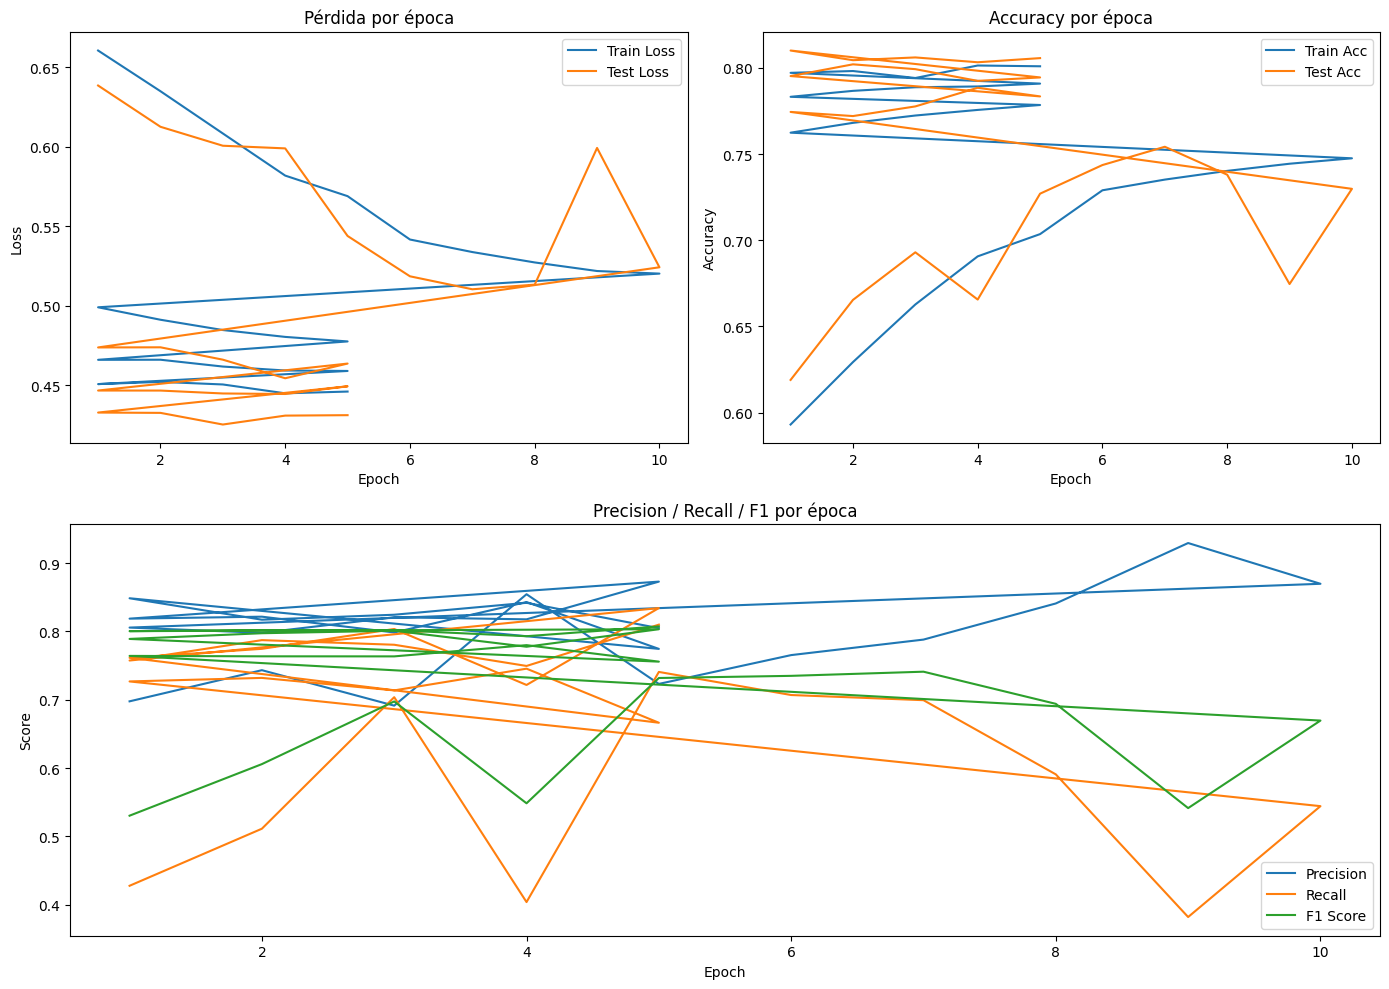

In [40]:
def graficar_historial(history):
    epochs = history["epoch"]

    plt.figure(figsize=(14, 10))

    # Loss
    plt.subplot(2, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["test_loss"], label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Pérdida por época")
    plt.legend()

    # Accuracy
    plt.subplot(2, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["test_acc"], label="Test Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy por época")
    plt.legend()

    # Precision, Recall y F1
    plt.subplot(2, 1, 2)
    plt.plot(epochs, history["precision"], label="Precision")
    plt.plot(epochs, history["recall"], label="Recall")
    plt.plot(epochs, history["f1"], label="F1 Score")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title("Precision / Recall / F1 por época")
    plt.legend()

    plt.tight_layout()
    plt.show()
graficar_historial(history)

In [26]:
# #Vamos a provar distintos parametros usando el RandomForestClassifier
# folder = '../data/processed/models/catdog/'
# file = 'model_keras.pkl'
# path = folder+file
# #Si el modelo aun no existe se procede a crear
# if not os.path.exists(path):
#     if not os.path.exists(folder):
#         os.makedirs(folder)
#     history = model.fit(train, epochs=10, validation_data=test)
#     joblib.dump(model, path)
# else:
#     #Carga el modelo si ya existe asi tarda menos
#     model = joblib.load(path)


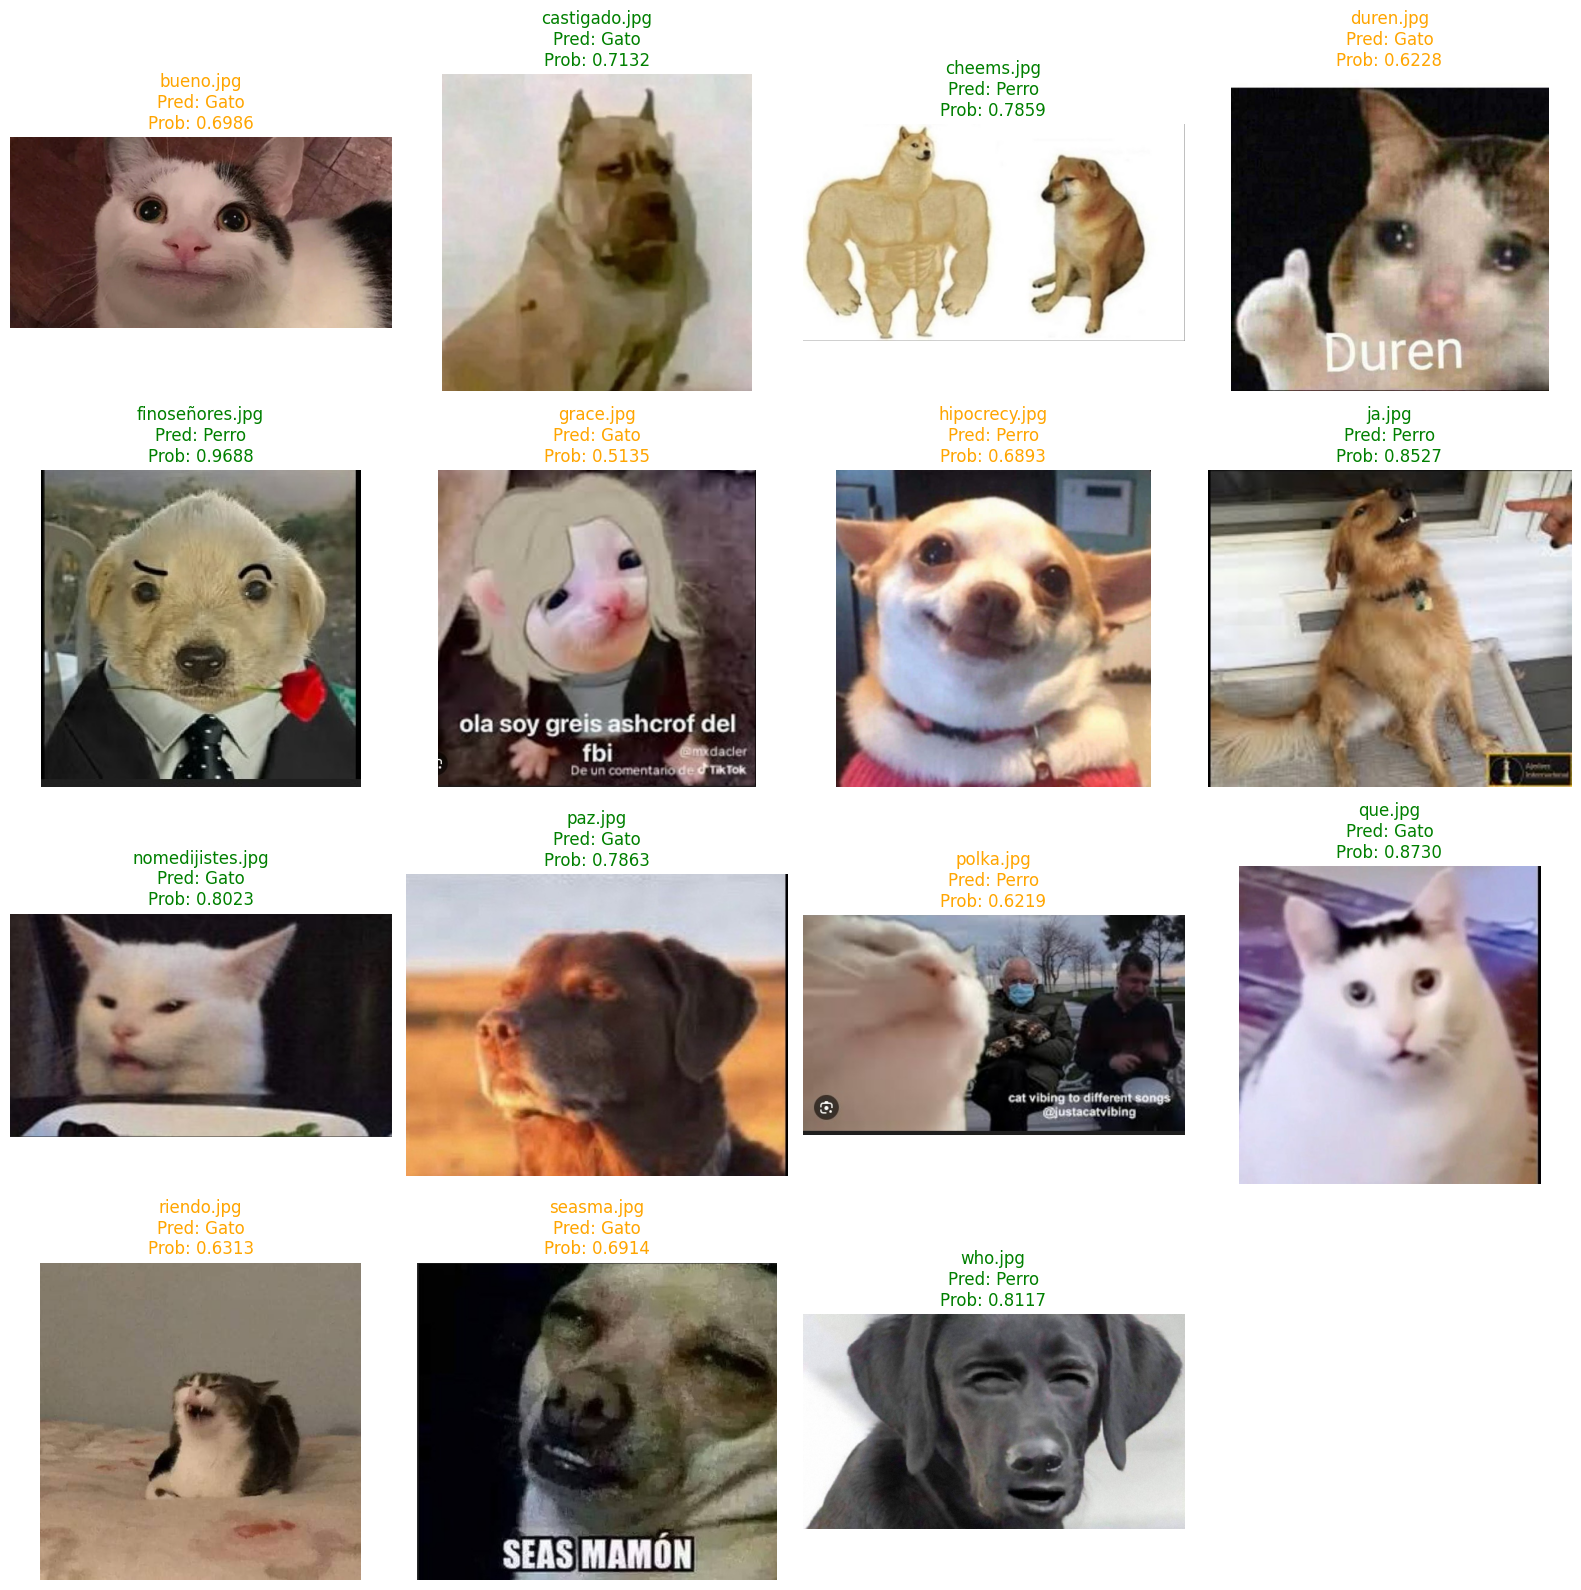

In [41]:
import os
from PIL import Image
import torch
import matplotlib.pyplot as plt

def graficar_predicciones_carpeta(ruta_carpeta, n_columnas=4):
    # Extensiones válidas
    extensiones = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

    # Obtener todas las imágenes de la carpeta
    lista_rutas = [
        os.path.join(ruta_carpeta, f)
        for f in os.listdir(ruta_carpeta)
        if f.lower().endswith(extensiones)
    ]

    # Ordenar para reproducibilidad
    lista_rutas.sort()

    if not lista_rutas:
        print("❌ No se encontraron imágenes en la carpeta.")
        return

    # Calcular filas
    n_imagenes = len(lista_rutas)
    n_filas = (n_imagenes + n_columnas - 1) // n_columnas

    plt.figure(figsize=(n_columnas * 4, n_filas * 4))

    for i, path in enumerate(lista_rutas):
        filename = os.path.basename(path)

        # 1. Cargar imagen
        image_raw = Image.open(path).convert("RGB")
        image_tensor = transform(image_raw)
        image_tensor = image_tensor.unsqueeze(0).to(device)

        # 2. Inferencia
        with torch.no_grad():
            output = model(image_tensor)
            probs = torch.softmax(output, dim=1)
            prob, pred = torch.max(probs, dim=1)

        pred = pred.item()
        prob = prob.item()
        label = "Perro" if pred == 1 else "Gato"

        # 3. Graficar
        plt.subplot(n_filas, n_columnas, i + 1)
        plt.imshow(image_raw)

        color = "green" if prob > 0.7 else "orange"

        plt.title(f"{filename}\nPred: {label}\nProb: {prob:.4f}", color=color)
        plt.axis("off")

    plt.tight_layout()
    plt.show()
    
graficar_predicciones_carpeta("../test/")
